[INFO] H-Optimus-1 | best CV bacc: ann_bacc = 0.8046
[INFO] Conch1_5 | best CV bacc: ann_bacc = 0.7165
[INFO] UNI2 | best CV bacc: ann_bacc = 0.7697
[INFO] Virchow2 | best CV bacc: ann_bacc = 0.7395
[INFO] ConchV1 | best CV bacc: ann_bacc = 0.7320
[OK] Merged CSV saved (15 rows) → d:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\Analysis_and_Visualization\TTC_Combinations_Exp\best_results_all.csv
[OK] Chart saved → d:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\Analysis_and_Visualization\TTC_Combinations_Exp\model_comparison_chart.png


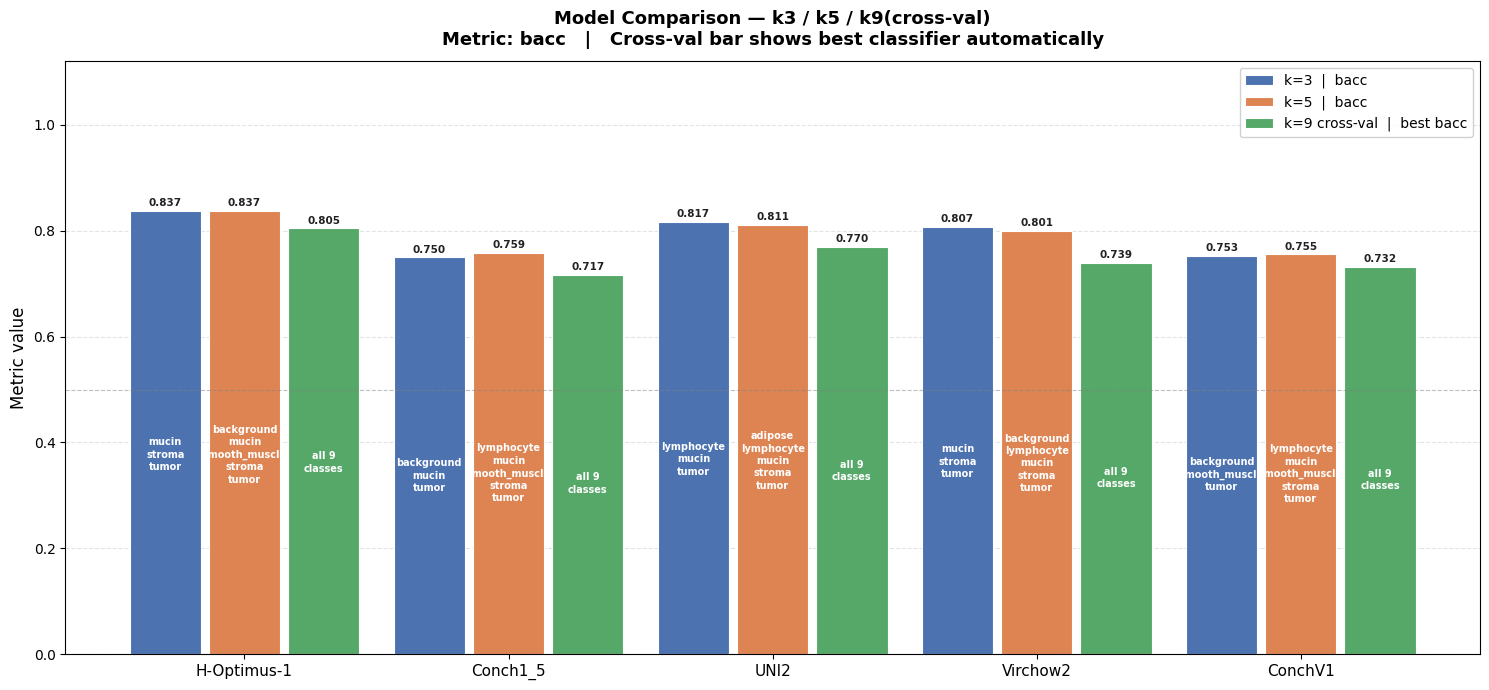

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

# ── Configuration ────────────────────────────────────────────────────────────
BASE_UPDATED = r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\slide_classification\TCGA_Results_Updated\Tissue_Type_Clustering"
BASE_ORIGINAL = r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\slide_classification\TCGA_Results\Tissue_Type_Clustering"

MODEL_NAMES = [
    "H-Optimus-1",
    "Conch1_5",
    "UNI2",
    "Virchow2",
    "ConchV1"
]

SUBFOLDER = r"1-MSIH\Output"

PLOT_METRIC = "bacc"

# ── Collectors ────────────────────────────────────────────────────────────────
rows_k3 = []
rows_k5 = []
rows_cv  = []

for model in MODEL_NAMES:
    for k, collector in [("k3", rows_k3), ("k5", rows_k5)]:
        path = os.path.join(BASE_UPDATED, model, SUBFOLDER, f"tissue_combo_summary_{k}.xlsx")
        if not os.path.exists(path):
            print(f"[WARN] Not found: {path}")
            continue
        df = pd.read_excel(path)
        if df.empty:
            print(f"[WARN] Empty file: {path}")
            continue
        top = df.iloc[[0]].copy()
        top.insert(0, "model_name", model)
        collector.append(top)

    cv_path = os.path.join(BASE_ORIGINAL, model, SUBFOLDER, "cross_valid_avg_eval_metrics.xlsx")
    if not os.path.exists(cv_path):
        print(f"[WARN] Not found: {cv_path}")
        continue
    df_cv = pd.read_excel(cv_path)
    if df_cv.empty:
        print(f"[WARN] Empty file: {cv_path}")
        continue
    df_cv.insert(0, "model_name", model)
    rows_cv.append(df_cv)

# ── Build per-source dataframes ───────────────────────────────────────────────
def concat_or_none(collector):
    if not collector:
        return None
    return pd.concat(collector, ignore_index=True)

df_k3_full = concat_or_none(rows_k3)
df_k5_full = concat_or_none(rows_k5)
df_cv_full = concat_or_none(rows_cv)

# ── Pick best CV row per model (highest AvgFolds for the chosen metric suffix) ─
def pick_best_cv_rows(df_cv, base_metric):
    best_rows = []
    if df_cv is None:
        return None
    for model in MODEL_NAMES:
        sub = df_cv[df_cv["model_name"] == model].copy()
        if sub.empty or "Metric" not in sub.columns:
            continue
        sub["Metric"] = sub["Metric"].astype(str)
        candidates = sub[sub["Metric"].str.strip().str.lower().str.endswith(base_metric.lower())]
        if candidates.empty or "AvgFolds" not in candidates.columns or candidates["AvgFolds"].isna().all():
            print(f"[WARN] No valid '{base_metric}' rows for model {model}")
            continue
        best_row = candidates.loc[candidates["AvgFolds"].idxmax()]
        best_rows.append(best_row.to_frame().T)
        print(f"[INFO] {model} | best CV {base_metric}: {best_row['Metric']} = {best_row['AvgFolds']:.4f}")
    return pd.concat(best_rows, ignore_index=True) if best_rows else None

df_cv_best = pick_best_cv_rows(df_cv_full, PLOT_METRIC)

# ── Tag each source and merge into one CSV ────────────────────────────────────
def tag(df, source_label):
    if df is None:
        return None
    d = df.copy()
    d.insert(1, "source", source_label)
    return d

tagged_k3 = tag(df_k3_full, "k3")
tagged_k5 = tag(df_k5_full, "k5")
tagged_cv = tag(df_cv_best, "k9_cross_val")

parts = [p for p in [tagged_k3, tagged_k5, tagged_cv] if p is not None]
out_dir = os.getcwd()

if parts:
    merged = pd.concat(parts, ignore_index=True)
    merged_path = os.path.join(out_dir, "best_results_all.csv")
    merged.to_csv(merged_path, index=False)
    print(f"[OK] Merged CSV saved ({len(merged)} rows) → {merged_path}")
else:
    print("[WARN] No data to save.")
    merged = None

# ── Extract values for chart ──────────────────────────────────────────────────
def get_tissue_values(df, metric_col, combo_col="combo"):
    results = {}
    if df is None:
        return results
    for model in MODEL_NAMES:
        sub = df[df["model_name"] == model]
        if sub.empty:
            results[model] = (None, "N/A")
            continue
        val   = sub.iloc[0].get(metric_col, None)
        combo = sub.iloc[0].get(combo_col, "N/A")
        if val is None or pd.isna(val):
            results[model] = (None, str(combo))
        else:
            results[model] = (float(val), str(combo))
    return results

def get_cv_chart_vals(df_cv_best, base_metric):
    results = {}
    if df_cv_best is None:
        return results
    for model in MODEL_NAMES:
        sub = df_cv_best[df_cv_best["model_name"] == model]
        if sub.empty:
            results[model] = (None, "N/A")
            continue
        val       = sub.iloc[0].get("AvgFolds", None)
        metric_lbl = sub.iloc[0].get("Metric", "N/A")
        if val is None or pd.isna(val):
            results[model] = (None, str(metric_lbl))
        else:
            results[model] = (float(val), str(metric_lbl))
    return results

k3_vals = get_tissue_values(df_k3_full, PLOT_METRIC)
k5_vals = get_tissue_values(df_k5_full, PLOT_METRIC)
cv_vals = get_cv_chart_vals(df_cv_best, PLOT_METRIC)

# ── Bar Chart ─────────────────────────────────────────────────────────────────
n      = len(MODEL_NAMES)
width  = 0.3
x      = np.arange(n)
colors = ["#4C72B0", "#DD8452", "#55A868"]
cond_labels = [f"k=3  |  {PLOT_METRIC}",
               f"k=5  |  {PLOT_METRIC}",
               f"k=9 cross-val  |  best {PLOT_METRIC}"]
offsets  = [-width, 0, width]
all_vals = [k3_vals, k5_vals, cv_vals]

fig, ax = plt.subplots(figsize=(15, 7))

for gi, (vals_dict, color, cond_label, offset) in enumerate(
        zip(all_vals, colors, cond_labels, offsets)):
    for mi, model in enumerate(MODEL_NAMES):
        val, anno = vals_dict.get(model, (None, "N/A"))
        if val is None:
            continue

        ax.bar(x[mi] + offset, val, width=width - 0.03,
               color=color, edgecolor="white", linewidth=0.8,
               label=cond_label if mi == 0 else "")

        # numeric value above bar
        ax.text(x[mi] + offset, val + 0.005, f"{val:.3f}",
                ha="center", va="bottom", fontsize=7.5,
                fontweight="bold", color="#222222")

        # For k9 cross-val bars always show a fixed clean label
        if gi == 2:
            label_text = "all 9\nclasses"
        else:
            # Split only on '+' so words never break mid-character
            parts = [p.strip() for p in anno.split("+") if p.strip()]
            label_text = "\n".join(parts) if parts else anno

        if val > 0.08:
            ax.text(x[mi] + offset, val * 0.45, label_text,
                    ha="center", va="center",
                    fontsize=7, color="white", fontweight="bold",
                    linespacing=1.3, clip_on=True,
                    multialignment="center")

ax.set_xticks(x)
ax.set_xticklabels(MODEL_NAMES, fontsize=11)
ax.set_ylabel("Metric value", fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_title(
    f"Model Comparison — k3 / k5 / k9(cross-val)\n"
    f"Metric: {PLOT_METRIC}   |   Cross-val bar shows best classifier automatically",
    fontsize=13, fontweight="bold", pad=12
)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax.yaxis.grid(True, linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

handles, lbls = ax.get_legend_handles_labels()
seen = dict(zip(lbls, handles))
ax.legend(seen.values(), seen.keys(), fontsize=10,
          loc="upper right", framealpha=0.9)   # moved to top-right

fig.tight_layout()
chart_path = os.path.join(out_dir, "model_comparison_chart.png")
fig.savefig(chart_path, dpi=150, bbox_inches="tight")
print(f"[OK] Chart saved → {chart_path}")
plt.show()